# Vérification du calage Gaussien non-linéaire

## Introduction

L'objectif de ce document est de vérifier la distribution des paramètres et des résidus d'un problème de moindres carrés non linéaires Gaussien. Plus précisément, on vérifie que les méthodes `getObservationsError` et `getParameterPosterior` de la classe `GaussianNonLinearCalibration` sont correctes.

On considère le modèle de Chaboche, présenté dans la documentation d'OpenTURNS :

http://openturns.github.io/openturns/master/usecases/use_case_chaboche.html

Le modèle de Chaboche est proche d'un modèle linéaire, sans être toutefois exactement linéaire.

La méthode de vérification est présentée dans "Vérification des moindres carrés linéaires". 

## Définit le modèle

In [1]:
import pylab as pl
import openturns.viewer as otv
import numpy as np
import openturns as ot
import otcalibration as otc
import matplotlib

matplotlib.rcParams["font.size"] = "12"
ot.RandomGenerator.SetSeed(0)

La cellule suivante définit le modèle physique.

In [2]:
def modelChaboche(X):
    strain, R, C, gamma = X
    stress = R + C * (1.0 - np.exp(-gamma * strain)) / gamma
    return [stress]

g = ot.PythonFunction(4, 1, modelChaboche)
g.setInputDescription(["Strain", r"R", r"C", r"Gamma"])
g.setOutputDescription(["Stress"])

trueR = 750.0
trueC = 2750.0
trueGamma = 10.0

trueParameter = ot.Point([trueR, trueC, trueGamma])

On définit ensuite la loi des résidus grâce à la loi gaussienne de moyenne nulle et d'écart-type 10. 

In [3]:
stressObservationNoiseSigma = 10.0  # (Pa)
observationOutputNoise = ot.Normal(0.0, stressObservationNoiseSigma)

La cellule suivante introduit le modèle paramétrique à caler. 

In [4]:
calibratedIndices = [1, 2, 3]
model = ot.ParametricFunction(g, calibratedIndices, trueParameter)

On définit les valeurs du paramètre _a priori_ de la loi gaussienne. 

In [5]:
candidateR = 700  # Exact : 750
candidateC = 2500  # Exact : 2750
candidateGamma = 8.0  # Exact : 10
candidate = ot.Point([candidateR, candidateC, candidateGamma])

On définit ensuite l'écart-type des erreurs d'observations, puis la matrice de covariance du modèle gaussien des erreurs d'observation.

In [6]:
sigmaStress = 10.0  # (Pa)
errorCovariance = ot.CovarianceMatrix(1)
errorCovariance[0, 0] = sigmaStress ** 2
errorCovariance

class=CovarianceMatrix dimension=1 implementation=class=MatrixImplementation name=Unnamed rows=1 columns=1 values=[100]

La cellule suivante définit la matrice de covariance du vecteur des paramètres $\theta$.

In [7]:
sigmaR = 0.1 * candidateR
sigmaC = 0.1 * candidateC
sigmaGamma = 0.1 * candidateGamma

parameterCovariance = ot.CovarianceMatrix(3)
parameterCovariance[0, 0] = sigmaR ** 2
parameterCovariance[1, 1] = sigmaC ** 2
parameterCovariance[2, 2] = sigmaGamma ** 2
parameterCovariance

class=CovarianceMatrix dimension=3 implementation=class=MatrixImplementation name=Unnamed rows=3 columns=3 values=[4900,0,0,0,62500,0,0,0,0.64]

## Calage

In [8]:
def calibrate_model(size, model, trueParameter, observationOutputNoise, candidate):
    """
    Génère un échantillon d'observations et réalise le calage.
    """
    data = np.linspace(0.0, 0.07, size)
    inputObservations = ot.Sample([[v] for v in data])
    # 1. Generate exact (deterministic) outputs
    model.setParameter(trueParameter)
    outputStress = model(inputObservations)
    # 2. Add noise
    sampleNoiseH = observationOutputNoise.getSample(size)
    outputObservations = outputStress + sampleNoiseH
    # 3. Calibrate
    model.setParameter(candidate)
    algo = ot.GaussianNonLinearCalibration(
        model,
        inputObservations,
        outputObservations,
        candidate,
        parameterCovariance,
        errorCovariance,
    )
    algo.run()
    calibrationResult = algo.getResult()
    return calibrationResult, inputObservations

size = 100

calibrationResult, inputObservations = calibrate_model(
    size, model, trueParameter, observationOutputNoise, candidate
)

thetaStarOT = calibrationResult.getParameterMAP()
print("thetaStarOT = ", thetaStarOT)

thetaPosterior = calibrationResult.getParameterPosterior()

covarianceThetaStarOT = thetaPosterior.getCovariance()
print("covarianceThetaStarOT = ")
print(covarianceThetaStarOT)

thetaStarOT =  [750.684,2643.49,8.1652]
covarianceThetaStarOT = 
[[    5.06742    -112.019        -0.00278785 ]
 [ -112.019      5119.43          1.73879    ]
 [   -0.00278785    1.73879       0.0487138  ]]


## Vérifie la distribution des résidus

On souhaite vérifier la distribution des résidus obtenus avec la méthode `getObservationsError`.

In [9]:
residualDistribution = calibrationResult.getObservationsError()
print("residualDistribution = ", residualDistribution)

sigma = residualDistribution.getParameter()[1]

residualDistribution =  Normal(mu = -0.0294681, sigma = 10)


On souhaite observer la distribution empirique de l'échantillon du résidu. Pour cela, on évalue l'échantillon des résidus et on approche sa distribution par lissage à noyau. 

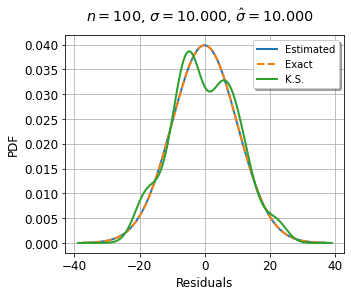

In [10]:
residualFunction = calibrationResult.getResidualFunction()
thetaMAP = calibrationResult.getParameterMAP()
residualPoint = residualFunction(thetaMAP)
residualSample = ot.Sample([[v] for v in residualPoint])
kernel = ot.KernelSmoothing()
fittedDist = kernel.build(residualSample)

graph = residualDistribution.drawPDF()
graph.setLegends(["Estimated"])
graphExact = observationOutputNoise.drawPDF().getDrawable(0)
graphExact.setLegend("Exact")
graphExact.setLineStyle("dashed")
graph.add(graphExact)
residualPDF = fittedDist.drawPDF()
residualPDF.setLegends(["K.S."])
graph.add(residualPDF)
graph.setTitle("$n=%d$, $\sigma=%.3f$, $\hat{\sigma}=%.3f$" % (size, stressObservationNoiseSigma, sigma))
graph.setLegendPosition("topright")
graph.setXTitle("Residuals")
graph.setColors(ot.Drawable_BuildDefaultPalette(3))
view = otv.View(graph, figure_kw={"figsize": (5.0, 4.0)})

La distribution des résidus est une hypothèse de calcul, c'est pourquoi les deux distributions coïncident nécessairement. On observe que la distribution empirique des résidus correspond approximativement à la distribution attendue. En effet, l'écart entre l'estimation de la distribution par lissage à noyau et la distribution exacte est acceptable, compte tenu de la petite taille de l'échantillon. 

## Distribution du résidu en fonction de la taille de l'échantillon

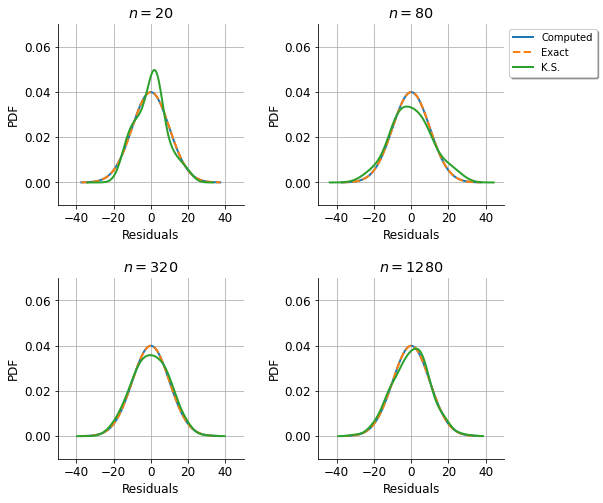

In [11]:
def simulate_and_plot_residuals(size, model, trueParameter, candidate):
    """
    Dessine la distribution des résidus.
    
    Parameters
    ----------
    size : int
        La taille de l'échantillon
    
    Returns
    -------
    graph : ot.Graph
        Le graphique
    """
    calibrationResult, inputObservations = calibrate_model(
        size, model, trueParameter, observationOutputNoise, candidate
    )

    # Analysis of the results
    thetaPosterior = calibrationResult.getParameterPosterior()

    # Draw residual distribution
    residualDistribution = calibrationResult.getObservationsError()

    residualFunction = calibrationResult.getResidualFunction()
    meanPosterior = calibrationResult.getParameterPosterior().getMean()
    posteriorResiduals = residualFunction(meanPosterior)
    residualsSample = ot.Sample([[v] for v in posteriorResiduals])

    kernel = ot.KernelSmoothing()
    fittedDist = kernel.build(residualsSample)
    residualPDF = fittedDist.drawPDF()
    residualPDF.setLegends(["K.S."])

    graph = residualDistribution.drawPDF()
    graph.setLegends(["Computed"])
    graphExact = observationOutputNoise.drawPDF().getDrawable(0)
    graphExact.setLineStyle("dashed")
    graphExact.setLegend("Exact")
    graph.add(graphExact)
    graph.add(residualPDF)
    graph.setLegendPosition("topleft")
    graph.setColors(ot.Drawable_BuildDefaultPalette(3))
    graph.setTitle("$n=%d$" % (size))
    graph.setXTitle("Residuals")
    bounding_box = ot.Interval([-50.0, -0.01], [50.0, 0.07])
    graph.setBoundingBox(bounding_box)
    return graph

grid = ot.GridLayout(2, 2)
graph = simulate_and_plot_residuals(20, model, trueParameter, candidate)
graph.setLegends([""])
grid.setGraph(0, 0, graph)
graph = simulate_and_plot_residuals(80, model, trueParameter, candidate)
grid.setGraph(0, 1, graph)
graph = simulate_and_plot_residuals(320, model, trueParameter, candidate)
graph.setLegends([""])
grid.setGraph(1, 0, graph)
graph = simulate_and_plot_residuals(1280, model, trueParameter, candidate)
graph.setLegends([""])
grid.setGraph(1, 1, graph)
view = otv.View(
    grid,
    figure_kw={"figsize": (8.0, 8.0)},
    legend_kw={"bbox_to_anchor": (1.0, 1.0), "loc": "upper left"},
)
pl.subplots_adjust(wspace=0.4, hspace=0.4)

On observe que la distribution des résidus converge vers la vraie distribution lorsque la taille de l'échantillon augmente. 

## Vérifie la distribution des paramètres

La classe `NonLinearGaussianCalibrationRandomVector` crée un vecteur aléatoire associé à l'estimateur du vecteur des paramètres.

In [12]:
nonlinearGaussianRandomVector = otc.NonLinearGaussianCalibrationRandomVector(
    model,
    trueParameter,
    inputObservations,
    observationOutputNoise,
    candidate,
    parameterCovariance,
    errorCovariance,
)
nonlinearGaussianRandomVector = ot.RandomVector(nonlinearGaussianRandomVector)
resampleSize = 20
sampleTheta = nonlinearGaussianRandomVector.getSample(resampleSize)
print(sampleTheta[0:5])

    [ x0         x1         x2         ]
0 : [  752.839   2538.37       8.20233 ]
1 : [  751.829   2578.55       8.17502 ]
2 : [  752.177   2580.31       8.16362 ]
3 : [  751.899   2580.47       7.8188  ]
4 : [  750.977   2639          8.21505 ]


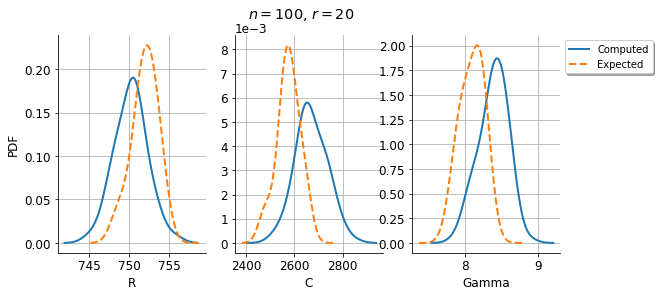

In [13]:
thetaPosterior = calibrationResult.getParameterPosterior()
parameterDimension = thetaPosterior.getDimension()

distributionTheta = ot.KernelSmoothing().build(sampleTheta)
grid = ot.GridLayout(1, parameterDimension)
for i in range(parameterDimension):
    thetai = thetaPosterior.getMarginal(i)
    graph = thetai.drawPDF()
    graph.setLegends(["Computed"])
    # From data
    curve = distributionTheta.getMarginal(i).drawPDF().getDrawable(0)
    curve.setLegend("Expected")
    curve.setLineStyle("dashed")
    graph.add(curve)
    if i != parameterDimension - 1:
        graph.setLegends([""])
    if i != 0:
        graph.setYTitle("")
    graph.setColors(ot.Drawable_BuildTableauPalette(2))
    grid.setGraph(0, i, graph)
grid.setTitle("$n=%d$, $r=%d$" % (size, resampleSize))
view = otv.View(grid, figure_kw = {"figsize": (9.0, 4.0)},
    legend_kw={"bbox_to_anchor": (1.0, 1.0), "loc": "upper left"})

## Convergence selon la taille de l'échantillon

On souhaite observer le comportement de l'estimation lorsque la taille de l'échantillon augmente.

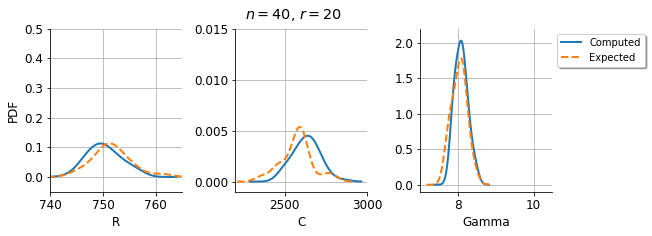

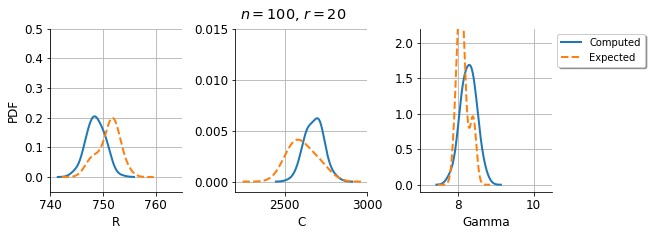

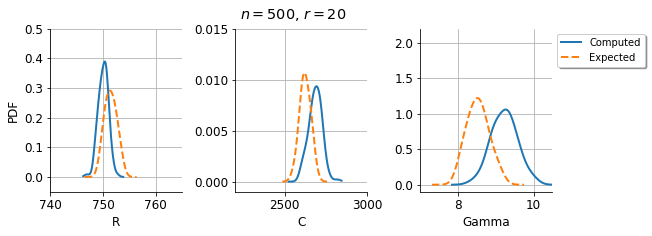

In [14]:
def simulate_and_plot_parameter(size, resampleSize=20):
    # Perform one calibration
    calibrationResult, inputObservations = calibrate_model(
        size, model, trueParameter, observationOutputNoise, candidate
    )
    thetaPosterior = calibrationResult.getParameterPosterior()
    # Generate a sample of theta
    nonlinearGaussianRandomVector = otc.NonLinearGaussianCalibrationRandomVector(
        model,
        trueParameter,
        inputObservations,
        observationOutputNoise,
        candidate,
        parameterCovariance,
        errorCovariance,
    )
    nonlinearGaussianRandomVector = ot.RandomVector(nonlinearGaussianRandomVector)
    sampleTheta = nonlinearGaussianRandomVector.getSample(resampleSize)
    distributionTheta = ot.KernelSmoothing().build(sampleTheta)
    # Plot
    parameterDimension = thetaPosterior.getDimension()
    grid = ot.GridLayout(1, parameterDimension)
    list_of_bounding_boxes = [
        ot.Interval([740.0, -0.05], [765.0, 0.5]),
        ot.Interval([2200.0, -0.001], [3000.0, 0.015]),
        ot.Interval([7.0, -0.1], [10.5, 2.2]),
    ]
    for i in range(parameterDimension):
        thetai = thetaPosterior.getMarginal(i)
        graph = thetai.drawPDF()
        graph.setLegends(["Computed"])
        # From data
        curve = distributionTheta.getMarginal(i).drawPDF().getDrawable(0)
        curve.setLegend("Expected")
        curve.setLineStyle("dashed")
        graph.add(curve)
        graph.setColors(ot.Drawable_BuildTableauPalette(2))
        if i > 0:
            graph.setYTitle("")
        if i != parameterDimension - 1:
            graph.setLegends([""])
        graph.setBoundingBox(list_of_bounding_boxes[i])
        grid.setGraph(0, i, graph)
    grid.setTitle("$n=%d$, $r=%d$" % (size, resampleSize))
    view = otv.View(
        grid,
        figure_kw={"figsize": (9.0, 3.0)},
        legend_kw={"bbox_to_anchor": (1.0, 1.0), "loc": "upper left"},
    )
    pl.subplots_adjust(wspace=0.4, hspace=0.4)
    return view

view = simulate_and_plot_parameter(40, resampleSize=20)

view = simulate_and_plot_parameter(100, resampleSize=20)

view = simulate_and_plot_parameter(500, resampleSize=20)

Pour les variables R et C, on observe que l'augmentation de la taille de l'échantillon provoque un resserrement de la distribution. On observe pas le même comportement pour la variable gamma. Ce n'est pas nécessairement un problème, car nous savons que la variable gamma n'est pas identifiable dans ce modèle. 